# Demonstrate how to convert healpix to lat/lon and then to iris cube

* Computes number of latitude and longitude points equating to input zoom (or define an analysis grid)
* Uses nearest neighbour interpolation.
* Plots the results using iris plotting.

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import intake
import matplotlib.pyplot as plt
import numpy as np

import healpy as hp
import xarray as xr
import iris
import iris.plot as iplt
import iris.quickplot as qplt

from utils import hp_mods, plot_all_fields

ERROR 1: PROJ: proj_create_from_database: Open of /home/users/hlewis/.conda/envs/hk26_env/share/proj failed


In [2]:
# Filter out annoying warning.
import warnings
warnings.filterwarnings("ignore", message=".*The return type of `Dataset.dims` will be changed.*", category=FutureWarning)

In [3]:
# Define function to compute number of latitude and longitude points appropriate for each Healpix zoom
# For more approximate computation, nlon ~ 4*nside; nlat ~ 3*nside
def healpix_zoom_to_grid_area_match(zoom):
    nside = 2.0**zoom

    # Healpix pixel area
    pixel_area = 4 * np.pi / (12 * nside**2)

    # Angular resolution
    theta = np.sqrt(pixel_area)

    # Compute nlon, nlat
    nlon = int(round(2 * np.pi / theta))
    nlat = int(round(np.pi / theta))

    return nlon, nlat

In [4]:
# Define function to translate from healpix to lat lon [could sit in utils.py, but showing here for transparency]
def get_nn_lon_lat_index(nside, lons, lats):
    lons2, lats2 = np.meshgrid(lons, lats)
    return xr.DataArray(
        hp.ang2pix(nside, lons2, lats2, nest=True, lonlat=True),
        coords=[("latitude", lats), ("longitude", lons)],
    )

In [5]:
# Define a function to generate iris cube from xarray Dataset
def xarray_to_iris(dataset, varname):

    # Clean up healpix attributes
    dataset["cell"].attrs.pop("standard_name", None)
    dataset["lat"].attrs.pop("standard_name", None)
    dataset["lon"].attrs.pop("standard_name", None)
    
    # Convert from xarray to iris cube
    cube = dataset[varname].to_iris()

    # Add more metadata to lat and lon coords
    for cube_coord in ["latitude", "longitude"]:
        cube.coord(cube_coord).units="degrees"
        cube.coord(cube_coord).coord_system=iris.coord_systems.GeogCS(6371229.0)
        cube.coord(cube_coord).guess_bounds()
        
    # Remove crs coord
    cube.remove_coord("crs")
    
    # Set standard_calendar for time coord
    cube.coord("time").units = cube.coord("time").units.change_calendar("standard")

    return cube

In [6]:
# Open catalog.
url = 'https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml'
cat = intake.open_catalog(url)['UK']
# Use online if not on JASMIN.
# cat = intake.open_catalog('https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml')['online']

In [7]:
# Print all catalog entries
print([k for k in cat])

['CERES_EBAF', 'ERA5', 'IR_IMERG', 'JRA3Q', 'MERRA2', 'arp-gem-1p3km', 'arp-gem-2p6km', 'casesm2_10km_nocumulus', 'icon_d3hp003', 'icon_d3hp003aug', 'icon_d3hp003feb', 'icon_ngc4008', 'ifs_tco3999-ng5_deepoff', 'ifs_tco3999-ng5_rcbmf', 'ifs_tco3999-ng5_rcbmf_cf', 'ifs_tco3999_rcbmf', 'nicam_220m_test', 'nicam_gl11', 'scream-dkrz', 'tracking-d3hp003', 'um_Africa_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26', 'um_Africa_km4p4_RAL3P3_n1280_GAL9_nest', 'um_Africa_km4p4_RAL3P3_n2560_CoMA9_nest_hk26', 'um_CTC_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26', 'um_CTC_km4p4_RAL3P3_n1280_GAL9_nest', 'um_CTC_km4p4_RAL3P3_n2560_CoMA9_nest_hk26', 'um_SAmer_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26', 'um_SAmer_km4p4_RAL3P3_n1280_GAL9_nest', 'um_SAmer_km4p4_RAL3P3_n2560_CoMA9_nest_hk26', 'um_SEA_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26', 'um_SEA_km4p4_RAL3P3_n1280_GAL9_nest', 'um_SEA_km4p4_RAL3P3_n2560_CoMA9_nest_hk26', 'um_glm_n1280_CoMA9_TBv1p2', 'um_glm_n1280_CoMA9_hk26', 'um_glm_n1280_GAL9', 'um_glm_n12

In [8]:
# Print all hk26 catalog entries
print('\n'.join([k for k in cat if k.endswith('_hk26')]))

um_Africa_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_Africa_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_CTC_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_CTC_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_SAmer_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_SAmer_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_SEA_km4p4_CoMA9_TBv1_n2560_CoMA9_hier_v2_hk26
um_SEA_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
um_glm_n1280_CoMA9_hk26
um_glm_n1280_GAL9_v2_hk26
um_glm_n2560_CoMA9_hk26
um_glm_n2560_RAL3p3_tuned_hk26


In [9]:
# Load specific model
sim = 'um_glm_n2560_RAL3p3_tuned_hk26'
sim_cat = cat()[sim]

In [10]:
# Open a 1h (2D) and 3h (3D) dataset - work with lo-res and hi-res example healpix
zoom_lr = 2
ds1h_lr = sim_cat(zoom=zoom_lr, time='PT1H').to_dask().pipe(hp_mods)
ds3h_lr = sim_cat(zoom=zoom_lr, time='PT3H').to_dask().pipe(hp_mods)

In [11]:
# Open a 1h (2D) and 3h (3D) dataset - work with lo-res and hi-res example healpix
zoom_hr = 8
ds1h_hr = sim_cat(zoom=zoom_hr, time='PT1H').to_dask().pipe(hp_mods)
ds3h_hr = sim_cat(zoom=zoom_hr, time='PT3H').to_dask().pipe(hp_mods)

In [12]:
ds1h_hr

<xarray.Dataset> Size: 920GB
Dimensions:  (time: 9745, cell: 786432, depth: 4)
Coordinates:
  * time     (time) datetime64[ns] 78kB 2020-01-20 ... 2021-03-01
  * cell     (cell) int64 6MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431
    lat      (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.2984 -0.1492
    lon      (cell) float64 6MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
  * depth    (depth) float32 16B 0.05 0.225 0.675 2.0
    crs      int64 8B 0
Data variables: (12/29)
    clivi    (time, cell) float32 31GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    clt      (time, cell) float32 31GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    clwvi    (time, cell) float32 31GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    hflso    (time, cell) float32 31GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    hfsso    (time, cell) float32 31GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    huss     (time, cell) float32 31GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    ...       ...
    rsutcs   (time, cell) float32 31GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    sftlf    (cell) float64 6MB dask.array<chunksize=(49152,), meta=np.ndarray>
    tas      (time, cell) float32 31GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    ts       (time, cell) float32 31GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    uas      (time, cell) float32 31GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
    vas      (time, cell) float32 31GB dask.array<chunksize=(16, 65536), meta=np.ndarray>
Attributes:
    regional_bounds:         {'lower_left_lat': -90, 'lower_left_lon': 0, 'up...
    latitiude_convention:    [-90, 90]
    longitude_convention:    [0, 360]
    regional:                False
    simulation:              glm.n2560_RAL3p3.tuned
    simulation_description:  The MetUM uses a regular lat-lon grid, for our e...
    processing_version:      v7
    deploy:                  prod
    summary:                 Met Office DYAMOND3 simulations: A group of expe...
    Conventions:             CF-1.13

In [13]:
# OPTION A: Define an analyisis grid (e.g. 1 degree global) - used to output all zoom levels to same analysis grid.
#           Caution uses nearest neighbour interpolation. May be useful for exploring data and testing ideas, or 
#           where matching to e.g. observations grid.
#           Either set bounds [lon1, lon2, lat1, lat2] based on input model domain extent, or user-specified
import ast
domain_bounds = ast.literal_eval(ds1h_hr.attrs.get("regional_bounds"))
lon1 = domain_bounds["lower_left_lon"]
lon2 = domain_bounds["upper_right_lon"]
nlon = 360
lons = np.linspace(lon1, lon2, nlon)

lat1 = domain_bounds["lower_left_lat"]
lat2 = domain_bounds["upper_right_lat"]
nlat = 180
lats = np.linspace(lat1, lat2, nlat)

# Get healpix_index coord corresponding to lat/lon mesh
idx_lr = get_nn_lon_lat_index(2**zoom_lr, lons, lats)
idx_hr = get_nn_lon_lat_index(2**zoom_hr, lons, lats)

In [14]:
len(idx_lr)

180

In [15]:
len(idx_hr)

180

In [16]:
ds1h_lr_latlon = ds1h_lr.isel(cell=idx_lr)
ds1h_hr_latlon = ds1h_hr.isel(cell=idx_hr)

ds3h_lr_latlon = ds3h_lr.isel(cell=idx_lr)
ds3h_hr_latlon = ds3h_hr.isel(cell=idx_hr)

In [17]:
ds1h_lr_latlon

<xarray.Dataset> Size: 76GB
Dimensions:    (time: 9745, latitude: 180, longitude: 360, depth: 4)
Coordinates:
  * time       (time) datetime64[ns] 78kB 2020-01-20 ... 2021-03-01
  * latitude   (latitude) float64 1kB -90.0 -88.99 -87.99 ... 87.99 88.99 90.0
  * longitude  (longitude) float64 3kB 0.0 1.003 2.006 ... 358.0 359.0 360.0
    cell       (latitude, longitude) int64 518kB 128 128 128 128 ... 63 63 63 15
    lat        (latitude, longitude) float64 518kB -78.28 -78.28 ... 78.28 78.28
    lon        (latitude, longitude) float64 518kB 45.0 45.0 45.0 ... 315.0 45.0
  * depth      (depth) float32 16B 0.05 0.225 0.675 2.0
    crs        int64 8B 0
Data variables: (12/29)
    clivi      (time, latitude, longitude) float32 3GB dask.array<chunksize=(4096, 1, 180), meta=np.ndarray>
    clt        (time, latitude, longitude) float32 3GB dask.array<chunksize=(4096, 1, 180), meta=np.ndarray>
    clwvi      (time, latitude, longitude) float32 3GB dask.array<chunksize=(4096, 1, 180), meta=np.ndarray>
    hflso      (time, latitude, longitude) float32 3GB dask.array<chunksize=(4096, 1, 180), meta=np.ndarray>
    hfsso      (time, latitude, longitude) float32 3GB dask.array<chunksize=(4096, 1, 180), meta=np.ndarray>
    huss       (time, latitude, longitude) float32 3GB dask.array<chunksize=(4096, 1, 180), meta=np.ndarray>
    ...         ...
    rsutcs     (time, latitude, longitude) float32 3GB dask.array<chunksize=(4096, 1, 180), meta=np.ndarray>
    sftlf      (latitude, longitude) float64 518kB dask.array<chunksize=(1, 180), meta=np.ndarray>
    tas        (time, latitude, longitude) float32 3GB dask.array<chunksize=(4096, 1, 180), meta=np.ndarray>
    ts         (time, latitude, longitude) float32 3GB dask.array<chunksize=(4096, 1, 180), meta=np.ndarray>
    uas        (time, latitude, longitude) float32 3GB dask.array<chunksize=(4096, 1, 180), meta=np.ndarray>
    vas        (time, latitude, longitude) float32 3GB dask.array<chunksize=(4096, 1, 180), meta=np.ndarray>
Attributes:
    regional_bounds:         {'lower_left_lat': -90, 'lower_left_lon': 0, 'up...
    latitiude_convention:    [-90, 90]
    longitude_convention:    [0, 360]
    regional:                False
    simulation:              glm.n2560_RAL3p3.tuned
    simulation_description:  The MetUM uses a regular lat-lon grid, for our e...
    processing_version:      v7
    deploy:                  prod
    summary:                 Met Office DYAMOND3 simulations: A group of expe...
    Conventions:             CF-1.13

In [18]:
#ds1h_lr_latlon["cell"].attrs.pop("standard_name", None)
#temp_cube_latlon_lr_A = ds1h_lr_latlon["tas"].to_iris()

In [19]:
temp_cube_latlon_lr_A = xarray_to_iris(ds1h_lr_latlon, "tas")

/home/users/hlewis/.conda/envs/hk26_env/lib/python3.14/site-packages/iris/common/mixin.py:212: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


In [20]:
#ds1h_hr_latlon["cell"].attrs.pop("standard_name", None)
#temp_cube_latlon_hr_A = ds1h_hr_latlon["tas"].to_iris()

In [21]:
temp_cube_latlon_hr_A = xarray_to_iris(ds1h_hr_latlon, "tas")

/home/users/hlewis/.conda/envs/hk26_env/lib/python3.14/site-packages/iris/common/mixin.py:212: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


In [22]:
temp_cube_latlon_lr_A

Air Temperature (K),time,latitude,longitude
Shape,9745,180,360
Dimension coordinates,,,
time,x,-,-
latitude,-,x,-
longitude,-,-,x
Auxiliary coordinates,,,
cell,-,x,x
lat,-,x,x
lon,-,x,x
Attributes,,,


In [23]:
temp_cube_latlon_hr_A

Air Temperature (K),time,latitude,longitude
Shape,9745,180,360
Dimension coordinates,,,
time,x,-,-
latitude,-,x,-
longitude,-,-,x
Auxiliary coordinates,,,
cell,-,x,x
lat,-,x,x
lon,-,x,x
Attributes,,,


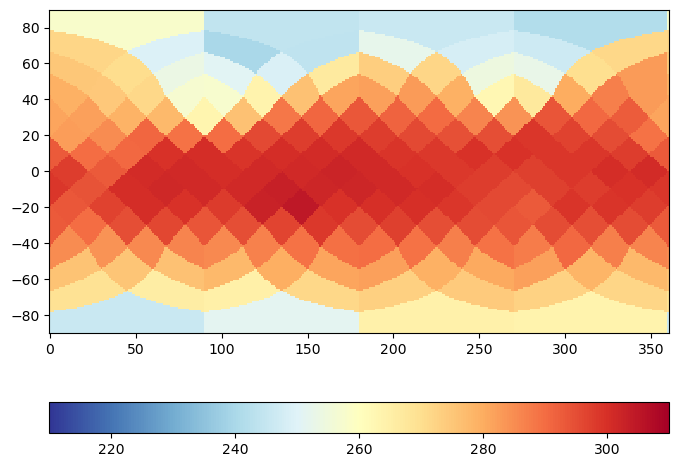

In [24]:
# Use iris plotting function with some user-defined options
# See https://scitools-iris.readthedocs.io/en/stable/ for more information on iris
plt.figure(figsize=(8,6))
iplt.pcolormesh(temp_cube_latlon_lr_A[1], vmin=210, vmax=310, cmap='RdYlBu_r')
plt.colorbar(orientation='horizontal')

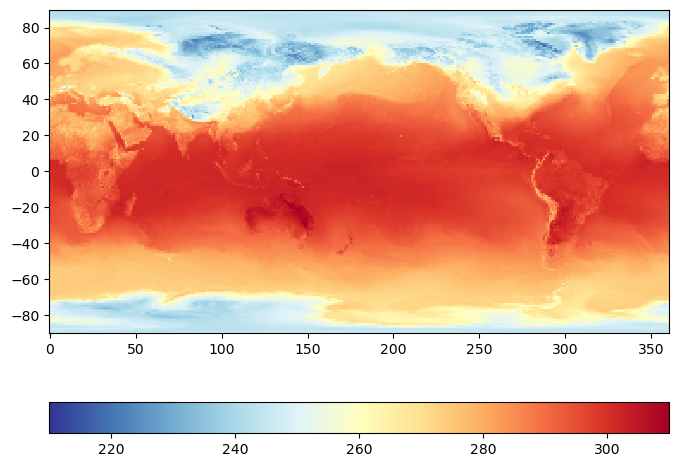

In [25]:
# Use iris plotting function with some user-defined options
# See https://scitools-iris.readthedocs.io/en/stable/ for more information on iris
plt.figure(figsize=(8,6))
iplt.pcolormesh(temp_cube_latlon_hr_A[1], vmin=210, vmax=310, cmap='RdYlBu_r')
plt.colorbar(orientation='horizontal')

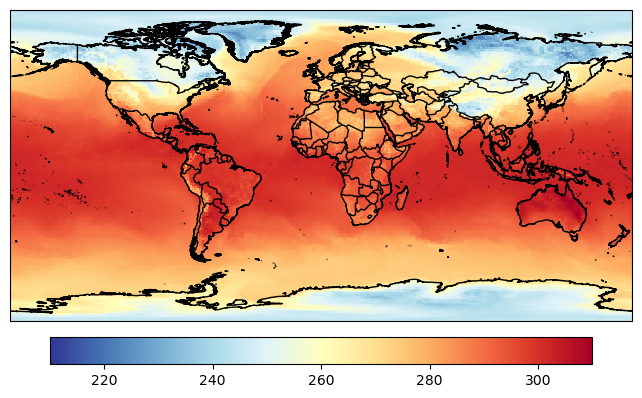

In [26]:
# More user-specified iris plotting options using cartopy
# See https://cartopy.readthedocs.io/stable/
fig = plt.figure(figsize=(10,5))
projection = ccrs.PlateCarree(central_longitude=0)
crs = ccrs.PlateCarree()
axes = fig.add_subplot(projection=projection)
iplt.pcolormesh(temp_cube_latlon_hr_A[1], vmin=210, vmax=310, cmap='RdYlBu_r')
axes.coastlines(resolution="10m", color='k')
axes.add_feature(cfeature.BORDERS, edgecolor='k')
plt.colorbar(orientation='horizontal',shrink=0.7, pad=0.042)

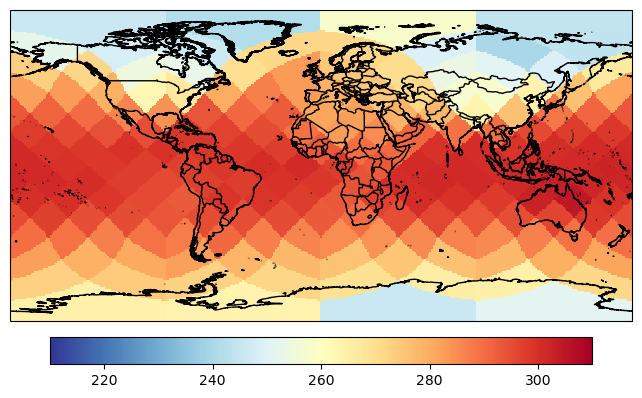

In [27]:
# More user-specified iris plotting options using cartopy
# See https://cartopy.readthedocs.io/stable/
fig = plt.figure(figsize=(10,5))
projection = ccrs.PlateCarree(central_longitude=0)
crs = ccrs.PlateCarree()
axes = fig.add_subplot(projection=projection)
iplt.pcolormesh(temp_cube_latlon_lr_A[1], vmin=210, vmax=310, cmap='RdYlBu_r')
axes.coastlines(resolution="10m", color='k')
axes.add_feature(cfeature.BORDERS, edgecolor='k')
plt.colorbar(orientation='horizontal',shrink=0.7, pad=0.042)

In [28]:
# OPTION B: (Recommended) Compute number of lat and lon points equivalent to Healpix zoom level
#          Note option to define lons [0,360] or [-180,180]
#          Either set bounds [lon1, lon2, lat1, lat2] based on input model domain extent, or user-specified
domain_bounds = ast.literal_eval(ds1h_hr.attrs.get("regional_bounds"))
lon1 = domain_bounds["lower_left_lon"]
lon2 = domain_bounds["upper_right_lon"]
lat1 = domain_bounds["lower_left_lat"]
lat2 = domain_bounds["upper_right_lat"]

# Call function to compute nlon, nlat based on zoom level
nlon_lr, nlat_lr = healpix_zoom_to_grid_area_match(zoom_lr) #, lat1, lat2, lon1, lon2)
lons_lr = np.linspace(lon1, lon2, nlon_lr)
lats_lr = np.linspace(lat1, lat2, nlat_lr)

nlon_hr, nlat_hr = healpix_zoom_to_grid_area_match(zoom_hr) #, lat1, lat2, lon1, lon2)
lons_hr = np.linspace(lon1, lon2, nlon_hr)
lats_hr = np.linspace(lat1, lat2, nlat_hr)

# Get healpix_index coord corresponding to lat/lon mesh
idx_lr = get_nn_lon_lat_index(2**zoom_lr, lons_lr, lats_lr)
idx_hr = get_nn_lon_lat_index(2**zoom_hr, lons_hr, lats_hr)

In [29]:
len(idx_lr)

12

In [30]:
len(idx_hr)

786

In [31]:
ds1h_lr_latlon = ds1h_lr.sel(cell=idx_lr)
ds3h_lr_latlon = ds3h_lr.sel(cell=idx_lr)

In [32]:
ds1h_hr_latlon = ds1h_hr.sel(cell=idx_hr)
ds3h_hr_latlon = ds3h_hr.sel(cell=idx_hr)

In [34]:
temp_cube_latlon_lr_B = xarray_to_iris(ds1h_lr_latlon, "tas")

/home/users/hlewis/.conda/envs/hk26_env/lib/python3.14/site-packages/iris/common/mixin.py:212: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


In [36]:
temp_cube_latlon_hr_B = xarray_to_iris(ds1h_hr_latlon, "tas")

/home/users/hlewis/.conda/envs/hk26_env/lib/python3.14/site-packages/iris/common/mixin.py:212: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


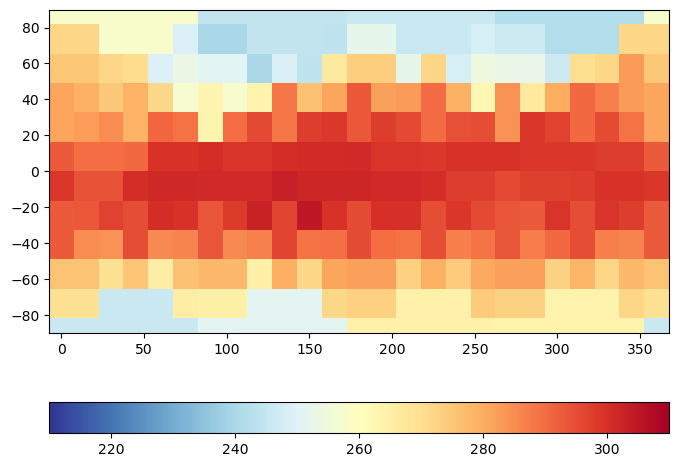

In [37]:
# Use iris plotting function with some user-defined options
# See https://scitools-iris.readthedocs.io/en/stable/ for more information on iris
plt.figure(figsize=(8,6))
iplt.pcolormesh(temp_cube_latlon_lr_B[1], vmin=210, vmax=310, cmap='RdYlBu_r')
plt.colorbar(orientation='horizontal')

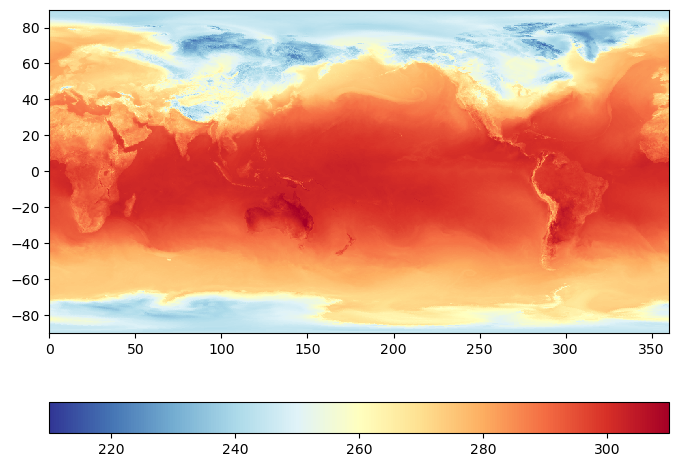

In [38]:
# Use iris plotting function with some user-defined options
# See https://scitools-iris.readthedocs.io/en/stable/ for more information on iris
plt.figure(figsize=(8,6))
iplt.pcolormesh(temp_cube_latlon_hr_B[1], vmin=210, vmax=310, cmap='RdYlBu_r')
plt.colorbar(orientation='horizontal')

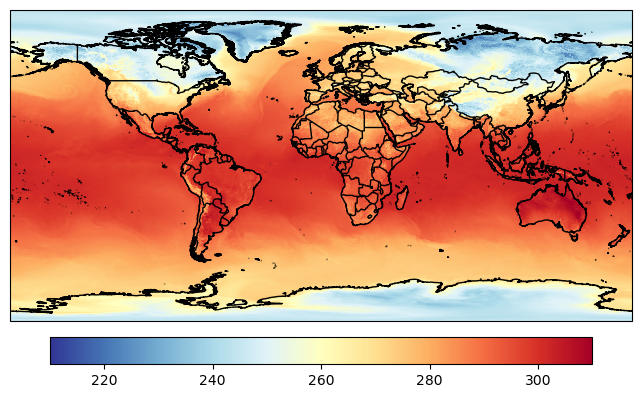

In [39]:
# More user-specified iris plotting options using cartopy
# See https://cartopy.readthedocs.io/stable/
fig = plt.figure(figsize=(10,5))
projection = ccrs.PlateCarree(central_longitude=0)
crs = ccrs.PlateCarree()
axes = fig.add_subplot(projection=projection)
iplt.pcolormesh(temp_cube_latlon_hr_B[1], vmin=210, vmax=310, cmap='RdYlBu_r')
axes.coastlines(resolution="10m", color='k')
axes.add_feature(cfeature.BORDERS, edgecolor='k')
plt.colorbar(orientation='horizontal',shrink=0.7, pad=0.042)

In [ ]:
# Use iris analysis to compute global average timeseries (only compute for lo-res input given global mean output)
t_mean_lr_A = temp_cube_latlon_lr_A.collapsed(["latitude","longitude"], iris.analysis.MEAN)
t_mean_lr_B = temp_cube_latlon_lr_B.collapsed(["latitude","longitude"], iris.analysis.MEAN)

In [ ]:
# Use iris analysis to compute global average timeseries (try hi-res input given global mean output)
t_mean_hr_A = temp_cube_latlon_hr_A.collapsed(["latitude","longitude"], iris.analysis.MEAN)
t_mean_hr_B = temp_cube_latlon_hr_B.collapsed(["latitude","longitude"], iris.analysis.MEAN)

In [ ]:
fig = plt.figure(figsize=(10,5))
iplt.plot(t_mean_lr_A, label="zoom 4, 360 x 180 grid")
iplt.plot(t_mean_lr_B, label="zoom 4, nlon x nlat grid")
iplt.plot(t_mean_hr_A, label="zoom 8, 360 x 180 grid")
iplt.plot(t_mean_hr_B, label="zoom 8, nlon x nlat grid")
plt.grid()
plt.legend()